In [2]:
print('start coding with bb3alien')

start coding with bb3alien


In [5]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import sparse
import dask.array as da
import numpy as np
import b3alien
from pyproj import Proj, Transformer
from shapely.geometry import mapping
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

%matplotlib inline
print('finished')

finished


In [7]:
# Load the GRIIS checklist

checklist_path = "../data/dwca-unified-checklist-v1.15/"
distribution = checklist_path + "distribution.txt"

df_cl = pd.read_csv(distribution, sep='\t', low_memory=False)

print('finished')

all checks are ok


In [11]:
# Specific issue due to the Belgian checklist
df_cl["speciesKey"] = df_cl["id"].str.rsplit("/", n=1).str[-1].astype("int64")
print('finished')

finished


In [13]:
df_cl.head()
print ('finished')

Finished


In [15]:
# 1. Filter rows where locality == 'Flemish Region' and eventDate is not missing
df = df_cl[df_cl["locality"] == "Flemish Region"].copy()
df = df[df["eventDate"].notna()]

exclusion_list = [
    "captive", "casual", "colonising", "cultivated",
    "failing", "NA|casual", "released", "reproducing", "transported"
]

df = df[~df["degreeOfEstablishment"].isin(exclusion_list)]

# 2. Split eventDate into intro and outro (assuming 'YYYY/MM' or 'YYYY/MM/YYYY/MM')
def split_event_date(x):
    if isinstance(x, str):
        parts = x.strip().split('/')
        if len(parts) == 2:
            intro = parts[0]
            outro = parts[1]
        else:
            intro = outro = np.nan
        return pd.Series([intro, outro])
    else:
        return pd.Series([np.nan, np.nan])

df[["introDate", "outroDate"]] = df["eventDate"].apply(split_event_date)

df["introDate"] = pd.to_datetime(df["introDate"], format="%Y", errors="coerce")
df["outroDate"] = pd.to_datetime(df["outroDate"], format="%Y", errors="coerce")


# 3. Clean rows with missing introDate
df_intro = df.dropna(subset=["introDate"]).copy()

# 4. Group by introDate and count species
in_species = (
    df_intro.groupby("introDate", sort=True)["id"]
    .count()
    .reset_index(name="nspec")
)

# 5. Cumulative sum
in_species["cumn"] = in_species["nspec"].cumsum()

# 6. Clean outro side and count outgoing species
df_outro = df.dropna(subset=["outroDate"]).copy()

out_species = (
    df_outro.groupby("outroDate", sort=True)["id"]
    .count()
    .reset_index(name="nspeco")
)

# 7. Merge intro and outro on date
n_species = pd.merge(in_species, out_species, how="outer", left_on="introDate", right_on="outroDate")

# 8. Replace NaNs with 0
n_species["nspec"] = n_species["nspec"].fillna(0).astype(int)
n_species["nspeco"] = n_species["nspeco"].fillna(0).astype(int)

# 9. Net species present at each time step
n_species["total"] = n_species["nspec"] - n_species["nspeco"]

# 10. Final frame with total species over time
tot_species = n_species[["introDate", "total"]].copy()

# 11. Optional: sort and compute cumulative total over time
tot_species = tot_species.sort_values("introDate")
tot_species["cumulative_total"] = tot_species["total"].cumsum()
print('finished')

finished


In [17]:
in_species

,introDate,nspec,cumn
0,1700-01-01,2,2
1,1711-01-01,1,3
2,1730-01-01,1,4
3,1792-01-01,1,5
4,1834-01-01,1,6
...,...,...,...
110,2021-01-01,90,1265
111,2022-01-01,54,1319
112,2023-01-01,44,1363
113,2024-01-01,2,1365


In [19]:
#save the table
in_species.to_csv("./output/total_newly_established_species_per_year_raw_data.csv", index=False)

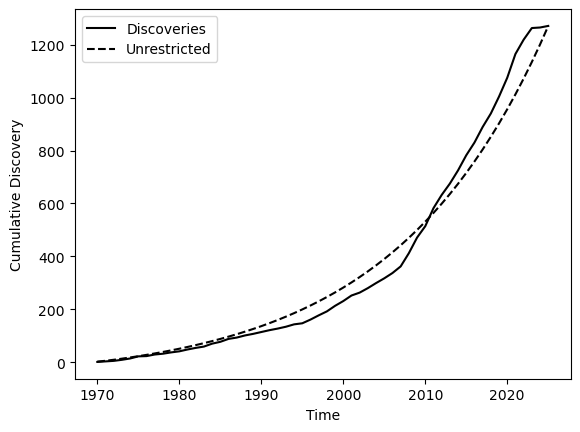

Finished


In [21]:
from b3alien import b3cube
from b3alien import griis
from b3alien import simulation

%matplotlib inline

def filter_time_window(df, start_year, end_year):
    """Filter time and rate based on year window."""
    filtered = df[(df["year"] >= start_year) & (df["year"] <= end_year)].reset_index(drop=True)
    return filtered["year"], filtered["rate"]


in_species["time"] = pd.to_datetime(in_species["introDate"])
in_species["cumulative_species"] = in_species["cumn"]

time, rate = b3cube.calculate_rate(in_species)


df = pd.DataFrame({
    "year": time,
    "rate": rate
})


# Here you can change the time period of the calculation
time, rate = filter_time_window(df, 1970, 2025)

C1, vec1 = simulation.simulate_solow_costello_scipy(time, rate, vis=True)

print('finished')

Bootstrapping: 100%|█████████████████████████████████████████████████████████████████| 100/100 [09:49<00:00,  5.90s/it]


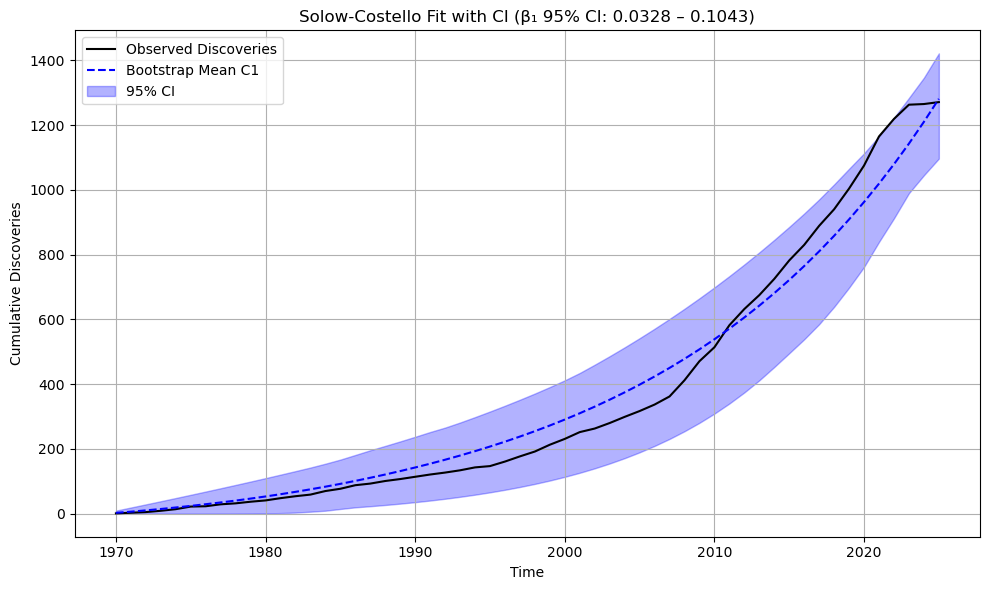

Finished


In [25]:
results = simulation.parallel_bootstrap_solow_costello(time, rate, n_iterations=100)

simulation.plot_with_confidence(time, rate, results)

print('finished')


In [27]:
rates_results = simulation.run_bootstrap_analysis(time, rate, n_iterations=200)
print('finished')

Starting 200 bootstrap iterations...

FITTING PARAMETERS RESULTS
Parameter vec1[1]: 0.058304 ± 0.018521

finished


In [29]:
rates_results

,Year,Annual_Rate,Annual_Rate_Error,Cumulative_Value,Cumulative_Error,Lower_CI_95,Upper_CI_95
0,1970,2.336289,2.076220,2.336289,2.076220,-1.733103,6.405681
1,1971,3.083180,2.237400,5.419469,4.281290,-1.302124,7.468484
2,1972,3.537949,2.353327,8.957418,6.586934,-1.074573,8.150470
3,1973,3.884566,2.443483,12.841985,8.972772,-0.904660,8.673793
4,1974,4.223041,2.517344,17.065026,11.387671,-0.710953,9.157034
5,1975,4.520708,2.598167,21.585733,13.862987,-0.571700,9.613115
6,1976,4.810442,2.651857,26.396175,16.390313,-0.387199,10.008083
7,1977,5.122326,2.692128,31.518501,18.939679,-0.154244,10.398897
8,1978,5.435464,2.708646,36.953966,21.518763,0.126519,10.744410
9,1979,5.819286,2.645337,42.773251,24.027597,0.634425,11.004146


In [31]:
rates_results.to_csv("./output/estimated_rates_solow_costello_effective_annual_rates_starting_1970_weak_filtering.csv", index=False)

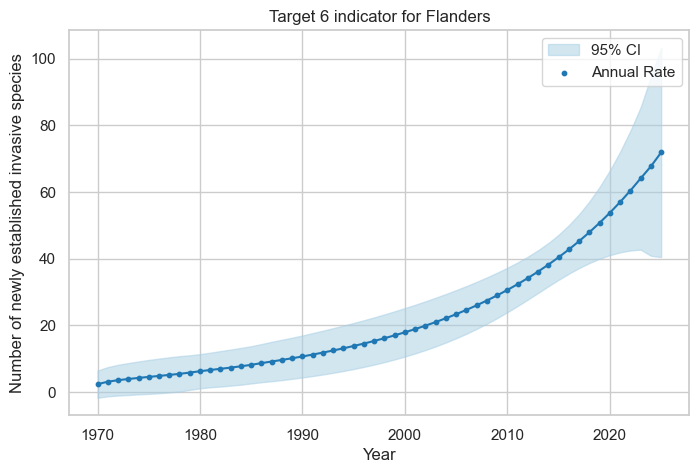

In [76]:
#draw plot of Target 6 indicator
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

df = rates_results
# Plot CI band
plt.fill_between(df['Year'], df['Lower_CI_95'], df['Upper_CI_95'], color='#a6cee3', alpha=0.5, label='95% CI')

# Plot punten van Annual_Rate
plt.scatter(df['Year'], df['Annual_Rate'], color='#1f78b4', s=10, label='Annual Rate')

# Verbinding van punten (lineaire)
plt.plot(df['Year'], df['Annual_Rate'], color='#1f78b4')

# Optioneel: smooth curve
# sns.lineplot(x='ear', y='Annual_Rate', data=df, color='blue', label='Smoothed Curve')

plt.xlabel('Year')
plt.ylabel('Number of newly established invasive species')
plt.title('Target 6 indicator for Flanders')
plt.legend()
#plt.show()
#print('Finished')
plt.savefig('./output/Figure_target6_indicator.png', dpi=200)

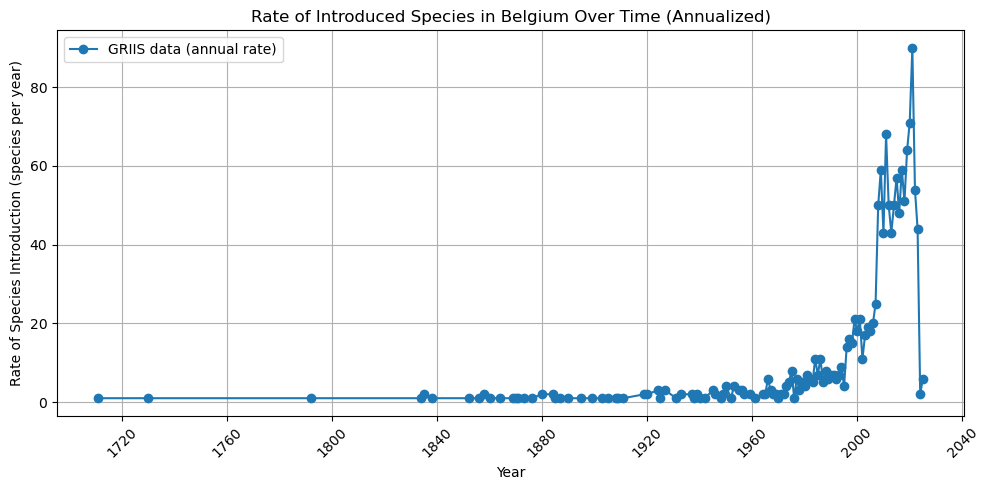

In [33]:
# --- Processing GRIIS data (Annual) ---
in_species["introDate"] = pd.to_datetime(in_species["introDate"])
in_species_rate = in_species.sort_values(by="introDate").copy()
in_species_rate["rate_per_year"] = in_species_rate["cumn"].diff()


# --- Plotting the rate of species (per year) ---
plt.figure(figsize=(10, 5))
#plt.plot(pd.to_datetime(annual_time_gbif, format='%Y'), annual_rate_gbif_series, marker="x", label="GBIF data (approx. annual rate)")
plt.plot(in_species_rate["introDate"][1:], in_species_rate["rate_per_year"][1:], marker="o", label="GRIIS data (annual rate)")
plt.title("Rate of Introduced Species in Belgium Over Time (Annualized)")
plt.xlabel("Year")
plt.ylabel("Rate of Species Introduction (species per year)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig("./output/Raw_data_new_species_per_year_figure.png")